# Trading With the Market: Turning Regimes Into Risk Control

### Motivation

While analysing markets, I realized that most strategies work beautifully in trending markets, but fail during bear phases, sideways corrections, or volatility spikes. Profits built over weeks often got erased in just a few bad phases.

That’s when I realized:

> **Trading strategies don’t fail because the logic is wrong. They fail because they are used in the wrong market environment.**

This project is an attempt to translate that qualitative understanding into a quantitative framework.

---

## Project Overview

In this notebook, we build a complete regime-based trading framework to:

- Understand market behavior using price and breadth data  
- Classify markets into bull, bear, high-volatility, and low-volatility regimes using Random Forest Model
- Stabilize noisy signals using persistence filters  
- Construct a four-regime adaptive exposure strategy and a Crash Hedge Strategy
- Add realistic execution logic  
- Backtest and evaluate performance against Buy & Hold  

The focus is not on predicting prices, but on:

> **Adapting risk and position sizing to changing market regimes.**


## Steps to Perform in This Project

1. Import libraries and load market data  
2. Build index-level and market breadth inputs
5. Define raw market regimes using rolling statistics  
3. Engineer trend, volatility, and breadth-based features  
4. Perform quality checks on features  
7. Train ML Models for Regime Classification
8. Classification Metrics for Each Regime  
9. Understand Feature Importance
10. Backtest the strategy   

Let’s begin!


In [52]:
# importing necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Index Data and Market Breadth Inputs

We start by building the primary data sources for the project.

- First, we download daily OHLCV data for a broad market index.
- Second, using all individual stocks within the index universe, we compute **market breadth metrics** that describe what’s happening beneath the surface.

Market breadth captures:
- Number of stocks above/below key moving averages  
- Number of stocks with large daily moves  
- Participation across the universe  

This helps us avoid relying only on index prices, which can often be dominated by a few large-cap stocks.


In [53]:
def fetch_historical_data(symbol, start_date, end_date):
    # Download historical data
    # threads=True speeds up download when fetching multiple symbols
    # group_by="symbol" ensures consistent structure across assets

  data = yf.download(symbol,start=start_date,end=end_date,threads=True,group_by="symbol")

    # yfinance returns MultiIndex columns when group_by="symbol" is used
    # For single-symbol downloads, flatten columns to standard OHLCV format

  if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(1)
  return data

In [54]:
def calculate_daily_indicators(data):
  #Computing basic daily indicators used for calculating Market Breadth
    data['MA20'] = data['Close'].rolling(window=20, min_periods=1).mean()     #calculating MA20
    data['MA50'] = data['Close'].rolling(window=50, min_periods=1).mean()     #calculating MA50
    data['Daily_Return'] = data['Close'].pct_change() * 100                   #percentage change in a day
    data['5Day_Return'] = (data['Close'] / data['Close'].shift(5) - 1) * 100  #percentage change in 5 days
    return data

In [55]:
def scan_single_stock_historical(symbol, start_date, end_date):
    """
    Scans historical price data for a single stock and generates
    daily technical condition flags.Then it returns a list of daily signal dictionaries
    """
    data = fetch_historical_data(symbol, start_date, end_date)

    data = calculate_daily_indicators(data)
    results = []

    # Start from index 50 to ensure MA50 is fully formed
    for i in range(50, len(data)):
        day = data.iloc[i]

    # Build a daily signal snapshot
        results.append({
            'Symbol': symbol,
            'Date': day.name.strftime('%Y-%m-%d'),

            # Price & volume
            'Close': day['Close'],
            'Volume': day['Volume'],

            # Moving averages
            'MA20': day['MA20'],
            'MA50': day['MA50'],

            # Returns
            'Daily_Return': day['Daily_Return'],
            '5Day_Return': day['5Day_Return'],

            # Trend conditions
            'Above_MA20': day['Close'] > day['MA20'],
            'Below_MA20': day['Close'] < day['MA20'],
            'Above_MA50': day['Close'] > day['MA50'],
            'Below_MA50': day['Close'] < day['MA50'],

            # Large daily move flags (momentum / shock detection)
            'Up_4.5pct_Today': day['Daily_Return'] >= 4.5,
            'Down_4.5pct_Today': day['Daily_Return'] <= -4.5,

            # Large multi-day move flags (short-term momentum)
            'Up_20pct_5Days': day['5Day_Return'] >= 20,
            'Down_20pct_5Days': day['5Day_Return'] <= -20
        })
    return results

In [56]:
def scan_all_stocks(symbols, start_date, end_date):
#Runs the historical scanner across a list of symbols and aggregates results.
  all_results = []
  for symbol in symbols:
    res = scan_single_stock_historical(symbol, start_date, end_date)
    all_results.extend(res)
    print(f"{symbol}: {len(res)} days processed")
  return pd.DataFrame(all_results)

In [57]:
def generate_daily_summary(df):
  
   daily_summary = df.groupby('Date').agg({
        'Symbol': 'count',
        'Above_MA20': 'sum',
        'Below_MA20': 'sum',
        'Above_MA50': 'sum',
        'Below_MA50': 'sum',
        'Up_4.5pct_Today': 'sum',
        'Down_4.5pct_Today': 'sum',
        'Up_20pct_5Days': 'sum',
        'Down_20pct_5Days': 'sum'
    }).reset_index()

   daily_summary.columns = [
        'Date', 'Total_Stocks_Scanned',
        'Stocks_Above_MA20', 'Stocks_Below_MA20',
        'Stocks_Above_MA50', 'Stocks_Below_MA50',
        'Stocks_Up_4.5pct_Today', 'Stocks_Down_4.5pct_Today',
        'Stocks_Up_20pct_5Days', 'Stocks_Down_20pct_5Days'
    ]
   return daily_summary.sort_values('Date')

In [58]:
def save_detailed_results(df, filename="data.csv"):
  #saves as a csv file
    df.to_csv(filename, index=False)
    print(f" Saved: {filename}")

In [59]:
import pandas as pd
import yfinance as yf

def download_nifty_index_ohlc(start_date, end_date, filename="nifty50_ohlc.csv"):
### Downloads historical OHLC data for the NIFTY 50 index from Yahoo Finance
### and saves it to a CSV file.
    
    # '^NSEI' is the ticker symbol for NIFTY 50 on Yahoo Finance
    ticker = "^NSEI"
    print(f"Downloading NIFTY 50 Index OHLC data for {ticker}")
    
    nifty50_data = yf.download(ticker, start=start_date, end=end_date, auto_adjust=True)
    
    if nifty50_data.empty:
        print(" Warning: No Index data found. Check your connection or ticker symbol.")
        return None
        
    ohlc_df = nifty50_data[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    ohlc_df.reset_index(inplace=True)
    
    # Flatten columns if yfinance returns multi-index headers
    if isinstance(ohlc_df.columns, pd.MultiIndex):
        ohlc_df.columns = [col[0] if col[1] == '' else col[0] for col in ohlc_df.columns]
        
    ohlc_df.to_csv(filename, index=False)
    print(f" Saved Index OHLC to: {filename}")
    return ohlc_df

if __name__ == "__main__":
    # 1. Define historical scan window (3-year window: gives the 90-day rolling
    #    z-score baseline enough history to classify regimes and produce more
    #    Bull/Bear/High-Vol transitions for the models to learn from)
    start_date = "2023-01-01"
    end_date = "2026-01-01"

    # 2. Extract and save the exact OHLC data of the NIFTY 50 Index
    nifty_50 = download_nifty_index_ohlc(start_date, end_date, "nifty50_ohlc.csv")

    # 3. Automatically fetch NIFTY 50 stock tickers directly from the official NSE link
    print("Fetching NIFTY 50 stock tickers directly from NSE...")
    try:
        nse_nifty50_url = "https://archives.nseindia.com/content/indices/ind_nifty50list.csv"
        df_symbols = pd.read_csv(nse_nifty50_url)[['Symbol']].copy()
        print(f"Loaded {len(df_symbols)} constituent symbols directly from NSE.")
    except Exception as e:
        print(f"Could not stream from NSE. Trying local fallback path... Error: {e}")
        # Local system absolute path fallback from your previous setup
        csv_path = r"C:\Users\Aagrim\Downloads\MLT02-Inclass-Exercises-File\MLT02 Inclass Exercises File\MLT02_data_ind_nifty50list"
        df_symbols = pd.read_csv(csv_path)[['Symbol']].copy()

    # Formulate Yahoo-compatible symbols (.NS)
    df_symbols['Yahoo_Symbol'] = df_symbols['Symbol'] + '.NS'
    symbols = df_symbols['Yahoo_Symbol'].tolist()

    # 4. Scan across the 50 individual stocks
    print(f" Initiating breadth scan for {len(symbols)} tickers...")
    all_results_df = scan_all_stocks(symbols, start_date, end_date)
    save_detailed_results(all_results_df, "all_stock_data.csv")

    # 5. Generate and save market breadth summary
    daily_summary_df = generate_daily_summary(all_results_df)
    save_detailed_results(daily_summary_df, "daily_summary.csv")

[*********************100%***********************]  1 of 1 completed

 Saved Index OHLC to: nifty50_ohlc.csv
Fetching NIFTY 50 stock tickers directly from NSE...



C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Loaded 50 constituent symbols directly from NSE.
 Initiating breadth scan for 50 tickers...
ADANIENT.NS: 690 days processed



C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

...

TATASTEEL.NS: 690 days processed
TECHM.NS: 690 days processed


C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


TITAN.NS: 690 days processed
TRENT.NS: 690 days processed


C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed
C:\Users\Aagrim\AppData\Local\Temp\ipykernel_27316\3365963335.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


ULTRACEMCO.NS: 690 days processed
WIPRO.NS: 690 days processed
 Saved: all_stock_data.csv
 Saved: daily_summary.csv


In [60]:
#loads the csv file created as data
data = pd.read_csv("daily_summary.csv",index_col=0,parse_dates=True)
data

,Total_Stocks_Scanned,Stocks_Above_MA20,Stocks_Below_MA20,Stocks_Above_MA50,Stocks_Below_MA50,Stocks_Up_4.5pct_Today,Stocks_Down_4.5pct_Today,Stocks_Up_20pct_5Days,Stocks_Down_20pct_5Days
Date,,,,,,,,,
2023-03-15,49,10,39,11,38,1,0,0,0
2023-03-16,49,15,34,14,35,1,1,0,0
2023-03-17,49,18,31,17,32,0,0,0,0
2023-03-20,49,15,34,16,33,0,0,0,0
2023-03-21,49,17,32,16,33,0,0,0,0
...,...,...,...,...,...,...,...,...,...
2025-12-24,50,30,20,26,24,0,0,0,0
2025-12-26,50,28,22,25,25,0,0,0,0
2025-12-29,50,22,28,23,27,0,0,0,0


In [61]:
#downloads the file in an excel format
data.to_excel("daily_stock_summary.xlsx", index=False)

In [62]:
nifty_50

,Date,Open,High,Low,Close,Volume
0,2023-01-02,18131.699219,18215.150391,18086.500000,18197.449219,256100
1,2023-01-03,18163.199219,18251.949219,18149.800781,18232.550781,208700
2,2023-01-04,18230.650391,18243.000000,18020.599609,18042.949219,235200
3,2023-01-05,18101.949219,18120.300781,17892.599609,17992.150391,269900
4,2023-01-06,18008.050781,18047.400391,17795.550781,17859.449219,238200
...,...,...,...,...,...,...
735,2025-12-24,26170.650391,26236.400391,26123.000000,26142.099609,188800
736,2025-12-26,26121.250000,26144.199219,26008.599609,26042.300781,142200
737,2025-12-29,26063.349609,26106.800781,25920.300781,25942.099609,234300
738,2025-12-30,25940.900391,25976.750000,25878.000000,25938.849609,396900


In [63]:
print(data.shape)
print(data.columns)
print(data.info())

(690, 9)
Index(['Total_Stocks_Scanned', 'Stocks_Above_MA20', 'Stocks_Below_MA20',
       'Stocks_Above_MA50', 'Stocks_Below_MA50', 'Stocks_Up_4.5pct_Today',
       'Stocks_Down_4.5pct_Today', 'Stocks_Up_20pct_5Days',
       'Stocks_Down_20pct_5Days'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 690 entries, 2023-03-15 to 2025-12-31
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Total_Stocks_Scanned      690 non-null    int64
 1   Stocks_Above_MA20         690 non-null    int64
 2   Stocks_Below_MA20         690 non-null    int64
 3   Stocks_Above_MA50         690 non-null    int64
 4   Stocks_Below_MA50         690 non-null    int64
 5   Stocks_Up_4.5pct_Today    690 non-null    int64
 6   Stocks_Down_4.5pct_Today  690 non-null    int64
 7   Stocks_Up_20pct_5Days     690 non-null    int64
 8   Stocks_Down_20pct_5Days   690 non-null    int64
dtypes: int64(9)
mem

In [64]:
print(nifty_50.shape)
print(nifty_50.columns)
print(nifty_50.info())

(740, 6)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    740 non-null    datetime64[ns]
 1   Open    740 non-null    float64       
 2   High    740 non-null    float64       
 3   Low     740 non-null    float64       
 4   Close   740 non-null    float64       
 5   Volume  740 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 34.8 KB
None


## Step 2: Market Regime Definition Using Trend & Volatility

In this step, we transform raw price data into structured **market regime labels** that serve as the target variable for the project.

We:
- Compute daily returns, rolling volatility, and lookback trend from prices.  
- Normalize trend and volatility using rolling z-scores so regime thresholds adapt over time.  
- Classify each day into raw Bull/Bear and High/Low volatility states based on these z-scores.  
- Apply persistence filters, requiring regimes to persist for at least **4 out of the last 5 days**, to reduce noise and whipsaws.  
- Drop initial periods with insufficient rolling data.

The output is a clean set of raw and stable regime indicators that describe the **market environment** and form the foundation for building the adaptive strategy in the next steps.

In [65]:
def define_market_regimes(prices, lookback=20):
## Defines market regimes(y variable) based on trend and volatility characteristics.

   # ----------------------------------------
   # Compute returns and rolling volatility
   # ----------------------------------------
   returns = prices.pct_change()
   rolling_vol = returns.rolling(lookback).std()
   trend = prices.pct_change(lookback)

   regimes = pd.DataFrame(index=prices.index)

   # ---------------------------------------------------------
   # Normalize volatility and trend using rolling z-scores
   # ---------------------------------------------------------
   # Z-scores are computed relative to a longer-term (90-day) baseline
   # This allows regime classification to adapt over time

   vol_zscore = (rolling_vol - rolling_vol.rolling(90).mean()) / rolling_vol.rolling(90).std()
   trend_zscore = (trend - trend.rolling(90).mean()) / trend.rolling(90).std()


   # ---------------------------------------------------------
   # Raw regime classification
   # ---------------------------------------------------------
   # Volatility regimes
   regimes["High_Volatility"] = (vol_zscore > 0.5).astype(int)
   regimes["Low_Volatility"] = (vol_zscore < -0.5).astype(int)

   # Trend regimes
   regimes["Bull_Market"] = (trend_zscore > 0.5).astype(int)
   regimes["Bear_Market"] = (trend_zscore < -0.5).astype(int)

   # ---------------------------------------------------------
   # Regime persistence filters
   # ---------------------------------------------------------
   # Require regime conditions to persist for at least
   # 4 out of the last 5 days to reduce whipsaws
   regimes["Stable_Bull"] = (
       (regimes["Bull_Market"] == 1) &
       (regimes["Bull_Market"].rolling(5).sum() >= 4)  # 4 of last 5 days
   ).astype(int)

   regimes["Stable_Bear"] = (
       (regimes["Bear_Market"] == 1) &
       (regimes["Bear_Market"].rolling(5).sum() >= 4)
   ).astype(int)

   regimes["Stable_Low_Vol"] = (
       (regimes["Low_Volatility"] == 1) &
       (regimes["Low_Volatility"].rolling(5).sum() >= 4)
   ).astype(int)

   # Drop initial rows with insufficient data for rolling calculations
   regimes = regimes.dropna()

   return regimes

## Step 3: Feature Creation

Using index prices and market breadth data, we construct features that capture:

- **Trend** → directional movement of the market  
- **Volatility** → risk and uncertainty  
- **Breadth strength & participation** → how widely moves are supported  

These features translate raw market data into signals that describe the *state* of the market rather than just its level.


For example, **Market_Momentum**((Stocks Above MA20 − Stocks Below MA20) / Total Stocks) measures the net balance of stocks above and below their short-term trend, helping distinguish sustainable trends from fragile rallies, while **Participation_Rate** ((Stocks Up + Stocks Down) / Total Stocks)captures how many stocks are actively moving, signaling whether volatility is expanding beneath the surface.


In [66]:
def create_regime_features(market_breadth, prices):
## Constructs predictive regime-level features using market breadth
## and index price data.
## All features are shifted to avoid look-ahead bias.
   print("\nSTEP 3: CREATING PREDICTIVE FEATURES...")

   features = pd.DataFrame(index=market_breadth.index)

   features['Advance_Decline_Ratio'] = (
      (market_breadth['Stocks_Up_4.5pct_Today'] + 1) /
      (market_breadth['Stocks_Down_4.5pct_Today'] + 1)
   )

   features['MA20_Strength'] = (
      market_breadth['Stocks_Above_MA20'] /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Market_Momentum'] = (
      (market_breadth['Stocks_Above_MA20'] - market_breadth['Stocks_Below_MA20']) /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Participation_Rate'] = (
      (market_breadth['Stocks_Up_4.5pct_Today'] + market_breadth['Stocks_Down_4.5pct_Today']) /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Extreme_Move_Ratio'] = (
      (market_breadth['Stocks_Up_20pct_5Days'] + market_breadth['Stocks_Down_20pct_5Days']) /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Extreme_Momentum_Bias'] = (
      (market_breadth['Stocks_Up_20pct_5Days'] - market_breadth['Stocks_Down_20pct_5Days']) /
      market_breadth['Total_Stocks_Scanned']
   )

   features['Extreme_Volatility_Indicator'] = (
      features['Extreme_Move_Ratio'].rolling(5).mean() /
      features['Extreme_Move_Ratio'].rolling(20).mean()
   )
   returns = prices.pct_change()
   features['Price_Volatility_Ratio'] = (
      (returns.rolling(5).std() / returns.rolling(20).std())
   )

   features['Trend_Strength'] = (
      (prices / prices.rolling(20).mean() - 1)
   )
   features = features.shift(1)

   lag_features = [
   'Advance_Decline_Ratio', 'MA20_Strength', 'Market_Momentum',
   'Participation_Rate', 'Extreme_Move_Ratio', 'Extreme_Momentum_Bias'
   ]
   for feat in lag_features:
     features[f'{feat}_lag1'] = features[feat].shift(1)

   features['Momentum_Change_5d'] = features['Market_Momentum'].diff(5)
   features['Breadth_Acceleration'] = features['MA20_Strength'].pct_change(3)
   features['Extreme_Momentum_Change'] = features['Extreme_Momentum_Bias'].diff(5)
   features['Extreme_Move_Acceleration'] = features['Extreme_Move_Ratio'].pct_change(3)

   # Replace any divide-by-zero infinities (e.g. volatility ratios when a
   # rolling denominator is 0) with NaN -- scikit-learn rejects inf at fit().
   features = features.replace([np.inf, -np.inf], np.nan)

   # On a small universe (e.g. NIFTY 50) stocks rarely move +/-20% in 5 days,
   # so Extreme_Move_Ratio is 0 on most days and its derived ratio/acceleration
   # features become 0/0 -> undefined on the majority of rows. Dropping those
   # rows would discard almost the entire sample (the '7 rows' symptom).
   # Treat 'no extreme activity' as a neutral 0 instead of dropping the row.
   neutral_fill = ['Extreme_Volatility_Indicator',
                   'Extreme_Move_Acceleration',
                   'Breadth_Acceleration']
   for col in neutral_fill:
       if col in features.columns:
           features[col] = features[col].fillna(0)

   # Remove only the initial warm-up rows (rolling/shift history)
   features = features.dropna()

   print(f" Features created successfully: {features.shape[1]} features, {features.shape[0]} rows")

   return features

In [67]:
# ---------------------------------------------------------
# Align market breadth data with price series
# ---------------------------------------------------------
# Create a working copy of market breadth data
market_breadth = data.copy()
# Extract index price series (e.g., NIFTY 500 close)
# Ensure the index price series is indexed by Date (not the default RangeIndex).
# download_nifty_index_ohlc() does reset_index(), so nifty_50 carries Date as a
# column with a 0..N RangeIndex. Without this conversion, intersecting the
# breadth DatetimeIndex with a RangeIndex yields ZERO common dates -> empty
# features (the all-NaN bug). Set Date as the index so alignment works.
nifty_50['Date'] = pd.to_datetime(nifty_50['Date'])
prices = nifty_50.set_index('Date')['Close']
# Find common dates between breadth data and price data
# This ensures features and targets are perfectly aligned
common_dates = market_breadth.index.intersection(prices.index)
# Subset both datasets to the shared date range
market_breadth = market_breadth.loc[common_dates]
prices = prices.loc[common_dates]

In [68]:
# ---------------------------------------------------------
# Generate regime-level predictive features
# ---------------------------------------------------------
# Transforms aligned market breadth and price data into lagged, look-ahead-safe features for regime modeling
features = create_regime_features(market_breadth, prices)


STEP 3: CREATING PREDICTIVE FEATURES...
 Features created successfully: 19 features, 669 rows


In [69]:
features_before = features.copy()

In [70]:
# ---------------------------------------------------------
# Feature normalization & outlier control
# ---------------------------------------------------------
# Log-transform skewed ratio-based features
log_features = [
    "Advance_Decline_Ratio",
    "Advance_Decline_Ratio_lag1",
    "Extreme_Move_Ratio",
    "Extreme_Move_Ratio_lag1",
    "Extreme_Momentum_Bias",
    "Extreme_Momentum_Bias_lag1"
]

for col in log_features:
    if col in features.columns:
        # clip lower bound just above -1 so log1p never returns -inf
        features[col] = np.log1p(features[col].clip(lower=-0.999999))

# ---------------------------------------------------------
# Clip acceleration features to control noise
# ---------------------------------------------------------
# Acceleration and change-based features are highly volatile
# Clipping prevents single-day shocks from dominating learning
clip_features = ["Breadth_Acceleration", "Extreme_Move_Acceleration"]

for col in clip_features:
    if col in features.columns:
        # Limit extreme outliers while preserving direction
        features[col] = features[col].clip(-3, 3)

## Step 4: Quality Check of Features

Before using the engineered features for modeling, we perform sanity checks to ensure:

- No extreme outliers dominate the signals  
- Ratios are well-behaved
- Check correlation matrix to spot highly correlated features
- Missing values are handled  
- Feature distribution using histograms to check for skewness or fatty tails

This step ensures the model learns from meaningful structure, not data artifacts.

In [71]:
# Check total missing values per column
print(features.isna().sum())

Advance_Decline_Ratio           0
MA20_Strength                   0
Market_Momentum                 0
Participation_Rate              0
Extreme_Move_Ratio              0
Extreme_Momentum_Bias           0
Extreme_Volatility_Indicator    0
Price_Volatility_Ratio          0
Trend_Strength                  0
Advance_Decline_Ratio_lag1      0
MA20_Strength_lag1              0
Market_Momentum_lag1            0
Participation_Rate_lag1         0
Extreme_Move_Ratio_lag1         0
Extreme_Momentum_Bias_lag1      0
Momentum_Change_5d              0
Breadth_Acceleration            0
Extreme_Momentum_Change         0
Extreme_Move_Acceleration       0
dtype: int64


In [72]:
print(features.describe())

       Advance_Decline_Ratio  MA20_Strength  Market_Momentum  \
count             669.000000     669.000000       669.000000   
mean                0.792927       0.594796         0.189593   
std                 0.333832       0.212779         0.425558   
min                 0.071459       0.061224        -0.877551   
25%                 0.693147       0.420000        -0.160000   
50%                 0.693147       0.620000         0.240000   
75%                 1.098612       0.760000         0.520000   
max                 2.890372       0.980000         0.960000   

       Participation_Rate  Extreme_Move_Ratio  Extreme_Momentum_Bias  \
count          669.000000          669.000000             669.000000   
mean             0.016483            0.001068               0.000530   
std              0.036505            0.004852               0.004962   
min              0.000000            0.000000              -0.020203   
25%              0.000000            0.000000               0.0

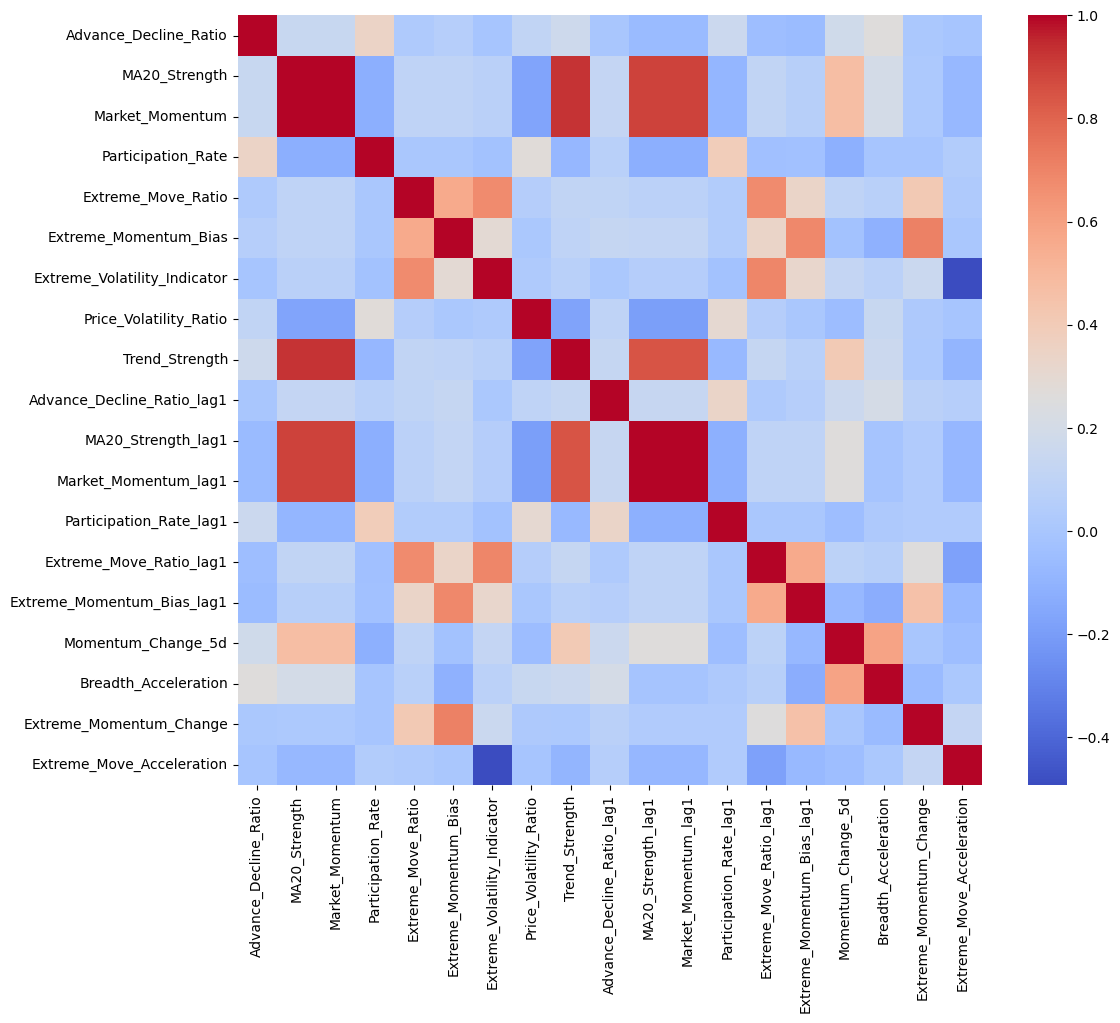

In [73]:
# Feature correlation analysis
corr = features.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.show()

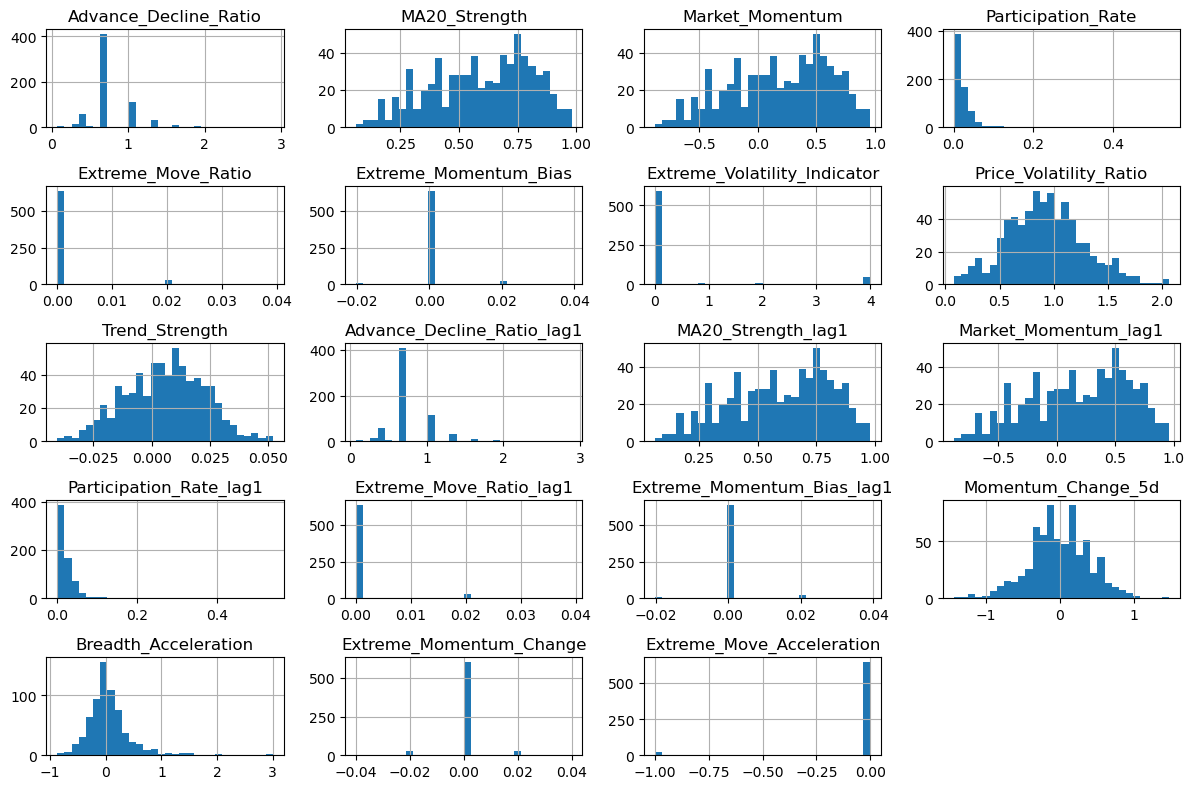

In [74]:
# Feature distribution inspection for skewness and outliers
features.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

In [75]:
changed_features = [
    col for col in features.columns
    if col in features_before.columns
    and not np.allclose(
        features_before[col].fillna(0),
        features[col].fillna(0)
    )
]

In [76]:
def plot_feature_changes(before, after, cols, bins=50):
    for col in cols:
        plt.figure(figsize=(8, 4))
        plt.hist(before[col].dropna(), bins=bins, alpha=0.6, label='Before')
        plt.hist(after[col].dropna(), bins=bins, alpha=0.6, label='After')
        plt.title(f"{col}: Before vs After")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

Changed features: ['Advance_Decline_Ratio', 'Extreme_Move_Ratio', 'Extreme_Momentum_Bias', 'Advance_Decline_Ratio_lag1', 'Extreme_Move_Ratio_lag1', 'Extreme_Momentum_Bias_lag1', 'Breadth_Acceleration']


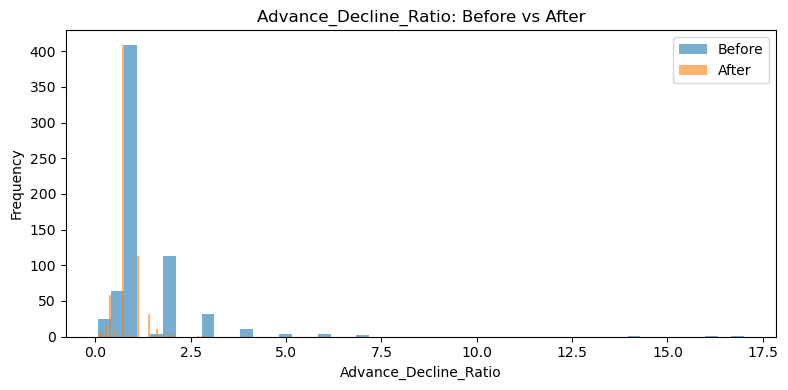

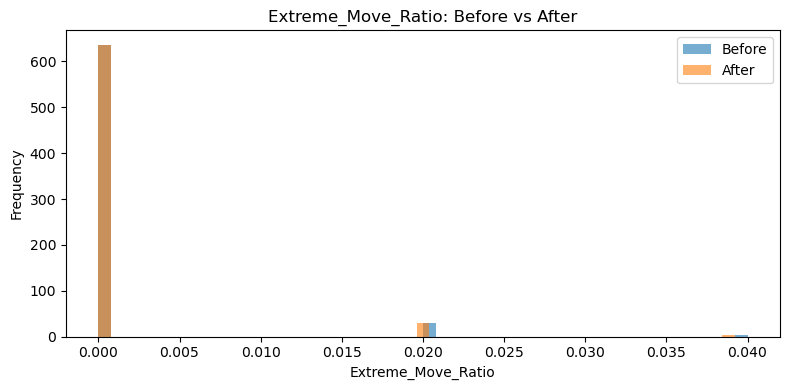

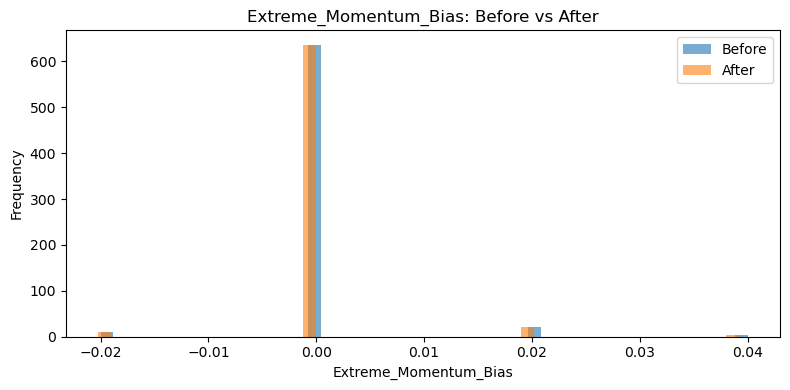

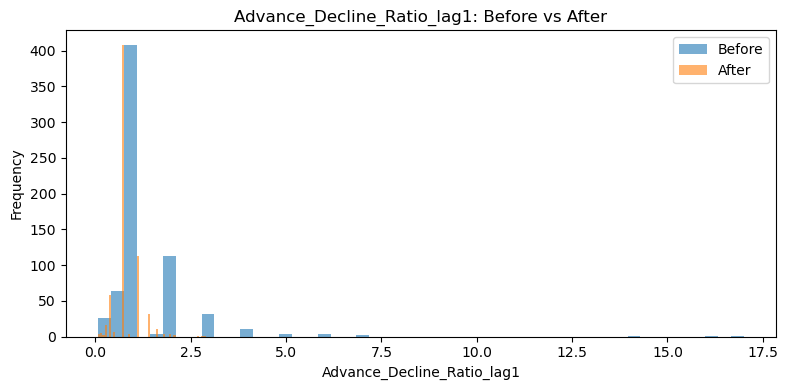

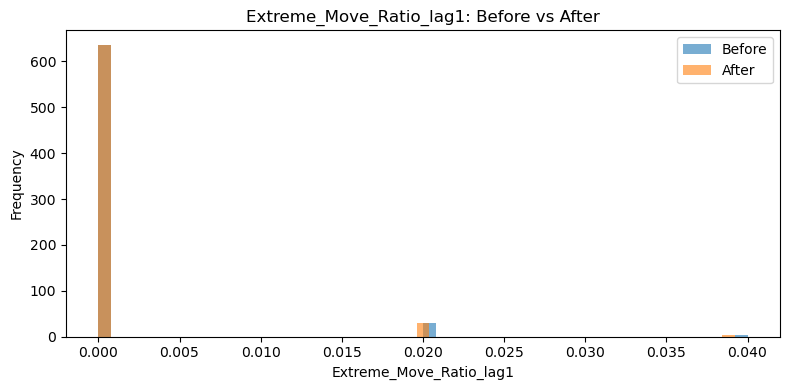

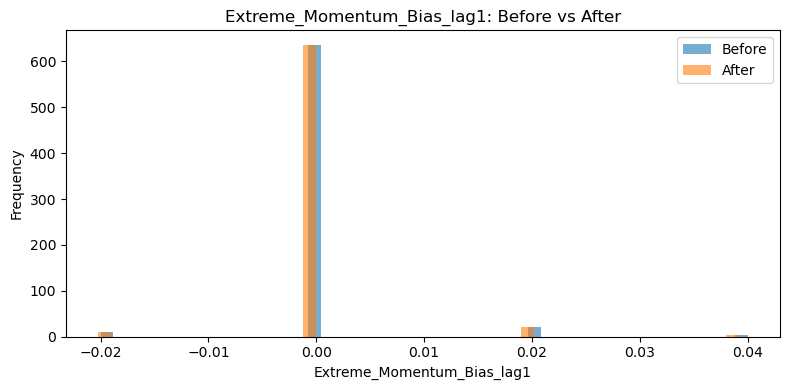

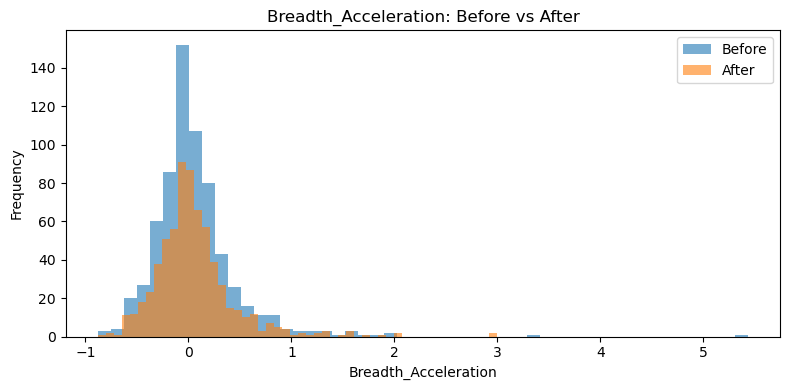

In [77]:
def plot_feature_changes(before, after, cols, bins=50):
    for col in cols:
        plt.figure(figsize=(8, 4))
        # Filter out non-finite values (NaN and inf) from 'before' data
        data_before = before[col].dropna()
        data_before = data_before[np.isfinite(data_before)]

        # Filter out non-finite values (NaN and inf) from 'after' data
        data_after = after[col].dropna()
        data_after = data_after[np.isfinite(data_after)]

        # Check if there's data to plot after filtering
        if not data_before.empty:
            plt.hist(data_before, bins=bins, alpha=0.6, label='Before')
        else:
            print(f"Warning: No finite data to plot for 'Before' in column '{col}'.")

        if not data_after.empty:
            plt.hist(data_after, bins=bins, alpha=0.6, label='After')
        else:
            print(f"Warning: No finite data to plot for 'After' in column '{col}'.")

        plt.title(f"{col}: Before vs After")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

print("Changed features:", changed_features)
plot_feature_changes(features_before, features, changed_features)

## Step 5: Train Time-Series ML Models for Regime Classification

In this step, we train machine learning models to **learn and predict market regimes** from engineered features.

We:
- Align feature data with regime labels by date and remove missing values.  
- Perform a time-aware train–test split to respect chronological order.  
- Use **Random Forest classifiers** with class balancing to handle regime imbalance.  
- Apply **walk-forward TimeSeries cross-validation** on the training set to assess stability across different market phases.  
- Train one **binary model per regime** (Bull, Bear, Low Vol, High Vol, etc.) instead of a single multi-class model.  
- Evaluate each model on a held-out test set using accuracy.  
- Save all trained models and diagnostics for later use.

This step converts engineered features into a set of predictive regime models, forming the bridge between **market data** and **regime-aware strategy construction** in the next stage.


In [78]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

def fit_evaluate_timeseries_rf(X, y, train_frac=0.7, n_splits=3, rf_kwargs=None):
## Fits and evaluates a Random Forest classifier on time-series data.
# Handle optional model hyperparameters
    rf_kwargs = rf_kwargs or {}

    # ---------------------------------------------------------
    # Train / test split (time-aware)
    # ---------------------------------------------------------
    # Use the first `train_frac` portion for training
    # Remaining data is held out as a final test set
    n = len(X)
    cut = int(n * train_frac)
    X_train, X_test = X.iloc[:cut], X.iloc[cut:]
    y_train, y_test = y.iloc[:cut], y.iloc[cut:]

    # ---------------------------------------------------------
    # TimeSeries cross-validation on training data
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_acc = []

    for tr_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        # Check if there are at least two unique classes in the training split
        if y_tr.nunique() < 2:
            print(f"Skipping CV fold due to insufficient data for training (only one class present).")
            continue

        # Train model on current fold
        m = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_kwargs)
        m.fit(X_tr, y_tr)

        # Check if there are at least two unique classes in the validation split for evaluation
        if y_val.nunique() < 2:
             print(f"Skipping CV fold evaluation due to insufficient data for validation (only one class present).")
             continue

        cv_acc.append(accuracy_score(y_val, m.predict(X_val)))

    # Final fit on full train
    model = RandomForestClassifier(random_state=42, n_jobs=-1, **rf_kwargs)
    model.fit(X_train, y_train)

    # Simple test eval
    test_acc = accuracy_score(y_test, model.predict(X_test))

    report = {
        "cv_fold_accuracy": cv_acc,
        "cv_mean_accuracy": float(np.mean(cv_acc)) if cv_acc else np.nan,
        "test_accuracy": float(test_acc),
        "train_size": int(len(X_train)),
        "test_size": int(len(X_test)),
    }
    return model, report

In [79]:
def train_all_regime_models(features, regimes, output_path="regime_models.pkl"):
  # Stores trained models and their evaluation reports
    models = {}
    reports = {}

    # Align features & regimes labels by date
    common_index = features.index.intersection(regimes.index)
    X = features.loc[common_index]  # input features
    Y = regimes.loc[common_index]   # regime labels

    # ---------------------------------------------------------
    # Train one binary model per regime
    # ---------------------------------------------------------
    for regime in Y.columns:
        print(f"\n Training model for regime: {regime}")
        y = Y[regime] # target for current regime (0/1)

        # Time-series RF with walk-forward CV and class balancing
        model, report = fit_evaluate_timeseries_rf(
            X=X,
            y=y,
            train_frac=0.7,
            n_splits=3,
            rf_kwargs={"n_estimators":100, "max_depth":10, "class_weight":"balanced"}
        )

        # Store model and diagnostics
        models[regime] = model
        reports[regime] = report
        print(report)

    # Save everything in one pickle file
    with open(output_path, "wb") as f:
        pickle.dump({"models": models, "reports": reports}, f)

    print(f"\nAll regime models saved to '{output_path}'")
    return models, reports


In [80]:
# 1. Create regime target labels from price series
regimes = define_market_regimes(prices, lookback=20)

# Align features & regimes labeled by date
common_index = features.index.intersection(regimes.index)
X = features.loc[common_index]
y = regimes.loc[common_index]

# Drop any remaining NaNs after alignment to ensure clean data for training
# This is crucial because define_market_regimes's final shift(1) introduces NaNs.
combined_data = pd.concat([X, y], axis=1)
combined_data.dropna(inplace=True)
X = combined_data[X.columns]
y = combined_data[y.columns]

# Split data into training and test sets
train_frac = 0.7
cut = int(len(X) * train_frac)
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y.iloc[:cut], y.iloc[cut:]
regimes_clean = y_test.copy() # Rename y_test to regimes_clean for clarity in evaluation function

# 2. Train and save all models
models, reports = train_all_regime_models(X_train, y_train, output_path="market_regime_models.pkl")

# 3. Evaluate models on test set
acc_table = pd.DataFrame(columns=['Regime', 'Accuracy'])
for regime in regimes_clean.columns:
    if regime in models:
        model = models[regime]
        # Check if there are at least two unique classes in the test split for evaluation
        if y_test[regime].nunique() < 2:
            print(f"Skipping test evaluation for regime '{regime}' due to insufficient data (only one class present).")
            continue
        test_acc = accuracy_score(regimes_clean[regime], model.predict(X_test))
        acc_table.loc[len(acc_table)] = [regime, test_acc]
    else:
        print(f"Model for regime '{regime}' not found.")

print("\n Test Set Evaluation:")
print(acc_table)


 Training model for regime: High_Volatility
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.4444444444444444, 0.5308641975308642], 'cv_mean_accuracy': 0.4876543209876543, 'test_accuracy': 0.41134751773049644, 'train_size': 327, 'test_size': 141}

 Training model for regime: Low_Volatility
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.8024691358024691, 0.5432098765432098], 'cv_mean_accuracy': 0.6728395061728395, 'test_accuracy': 0.6879432624113475, 'train_size': 327, 'test_size': 141}

 Training model for regime: Bull_Market
Skipping CV fold due to insufficient data for training (only one class present).
{'cv_fold_accuracy': [0.9012345679012346, 0.5802469135802469], 'cv_mean_accuracy': 0.7407407407407407, 'test_accuracy': 0.8297872340425532, 'train_size': 327, 'test_size': 141}

 Training model for regime: Bear_Market
Skipping CV fold due to insufficient data for training

In [81]:
# ---------------------------------------------------------
# Align feature matrix with price data used for prediction
# ---------------------------------------------------------
# Ensure features and prices share the same timeline
common_index = features.index.intersection(prices.index)
X = features.loc[common_index]
close = prices.loc[common_index]

# ---------------------------------------------------------
# Initialize signal DataFrame
# ---------------------------------------------------------
# Stores regime predictions aligned with dates and prices
signals = pd.DataFrame(index=common_index)
signals["Close"] = close

# ---------------------------------------------------------
# Generate regime signals using trained models
# ---------------------------------------------------------
# Each model predicts whether its regime is active (0/1)
for regime_name, model in models.items():
    signals[regime_name] = model.predict(X)

In [82]:
signals.tail()

,Close,High_Volatility,Low_Volatility,Bull_Market,Bear_Market,Stable_Bull,Stable_Bear,Stable_Low_Vol
Date,,,,,,,,
2025-12-24,26142.099609,1,1,0,1,0,0,0
2025-12-26,26042.300781,1,1,0,0,0,0,0
2025-12-29,25942.099609,1,1,0,1,0,0,0
2025-12-30,25938.849609,0,0,0,1,0,0,0
2025-12-31,26129.599609,0,0,0,0,0,0,0


In [83]:
signals.to_csv("market_regime_signals.csv")

## Step 6: Detailed Classification Metrics for Each Regime

In this step, we go beyond accuracy and evaluate each regime model using:

- **Precision** → how reliable positive regime predictions are  
- **Recall** → how well the model captures actual regime occurrences  
- **F1-score** → balance between precision and recall  

For each trained binary regime model, we generate a full classification report on the test set.

This helps us understand:
- Which regimes are easier or harder to detect,  
- Whether the model is biased toward false positives or false negatives, and  
- If regime predictions are robust enough to be used in downstream strategy logic.


In [84]:
from sklearn.metrics import classification_report

print("\n" + "="*50)
print("PRECISION, RECALL, F1-SCORE FOR EACH REGIME")
print("="*50)

for regime_name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n {regime_name}:")
    print(classification_report(y_test[regime_name], y_pred))


PRECISION, RECALL, F1-SCORE FOR EACH REGIME

 High_Volatility:
              precision    recall  f1-score   support

           0       0.79      0.86      0.83       161
           1       0.15      0.10      0.12        40

    accuracy                           0.71       201
   macro avg       0.47      0.48      0.47       201
weighted avg       0.67      0.71      0.69       201


 Low_Volatility:
              precision    recall  f1-score   support

           0       0.41      0.83      0.55        76
           1       0.73      0.29      0.41       125

    accuracy                           0.49       201
   macro avg       0.57      0.56      0.48       201
weighted avg       0.61      0.49      0.47       201


 Bull_Market:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       136
           1       0.92      0.34      0.49        65

    accuracy                           0.78       201
   macro avg       0.84      0.

In [85]:
def feature_importance_table(models, X_train, round_decimals=4):
    """
    Returns a sorted feature importance table:
    Rows   -> Features (sorted by mean importance)
    Columns-> Regimes
    Values -> Feature Importance
    """
#Code to print a table that shows tree-based feature importance extracted from separate
#Random Forest models trained for different market regimes.
#Higher values indicate that the model relied more heavily on that feature when making predictions.

    tables = []

    for regime, model in models.items():
        tables.append(
            pd.Series(
                model.feature_importances_,
                index=X_train.columns,
                name=regime
            )
        )

    importance_table = pd.concat(tables, axis=1)

    # ---- Sort by overall importance ----
    importance_table["Mean_Importance"] = importance_table.mean(axis=1)
    importance_table = importance_table.sort_values(
        by="Mean_Importance",
        ascending=False
    )

    return importance_table.round(round_decimals)

## Step 7: Feature Importance Analysis

In this step, we analyze feature importance from the trained Random Forest models to understand:

> **Which signals drive regime classification, and how their relevance changes across market environments.**

### Key Observations

**1️⃣ Universal Signals**  
Across all regimes, the most influential features are:
- **Trend_Strength** *(Index price relative to its 20-day MA)*  
- **Market_Momentum** *((Stocks above MA20 − Stocks below MA20) / Total stocks)*  
- **MA20 Strength** *(Stocks above MA20 / Total stocks)*  

These features consistently rank at the top because they capture **directional persistence and participation**, which remain important regardless of regime.

**2️⃣ Regime-Specific Signals**  
- **Extreme_Momentum_Change** and **Breadth_Acceleration** become more important during **high-volatility and transition regimes**, reflecting sudden shifts in market behavior.  
- **Participation-based features** dominate in **low-volatility and stable regimes**, where broad-based strength matters more than extremes.

### Interpretation

The results show that:
- Core trend and breadth signals explain market structure across all regimes.  
- Additional features gain importance depending on the market environment, indicating that **drivers of predictability are regime-dependent**.

This validates the motivation of the project:
> Different regimes are governed by different signals, and adaptive strategies should respect that.


In [86]:
feature_importance = feature_importance_table(models=models,X_train=X_train)
feature_importance

,High_Volatility,Low_Volatility,Bull_Market,Bear_Market,Stable_Bull,Stable_Bear,Stable_Low_Vol,Mean_Importance
Trend_Strength,0.1260,0.1297,0.3110,0.1990,0.3124,0.2274,0.1347,0.2058
Market_Momentum_lag1,0.0835,0.0799,0.1087,0.1273,0.1420,0.1578,0.0790,0.1112
Market_Momentum,0.0904,0.0733,0.0986,0.1538,0.1130,0.1046,0.0811,0.1021
Price_Volatility_Ratio,0.1506,0.1113,0.0829,0.0677,0.0622,0.0547,0.1469,0.0966
MA20_Strength,0.0763,0.0679,0.0766,0.1087,0.0873,0.0927,0.0874,0.0853
MA20_Strength_lag1,0.0793,0.0751,0.0749,0.0942,0.0870,0.1002,0.0673,0.0826
Momentum_Change_5d,0.1201,0.1151,0.0483,0.0691,0.0432,0.0605,0.0988,0.0793
Breadth_Acceleration,0.0936,0.0891,0.0505,0.0659,0.0477,0.0780,0.0949,0.0742
Participation_Rate_lag1,0.0432,0.0301,0.0437,0.0222,0.0290,0.0248,0.0379,0.0330
Advance_Decline_Ratio_lag1,0.0304,0.0389,0.0356,0.0218,0.0277,0.0281,0.0325,0.0307


## Step 8: Backtesting & Evaluating the Regime-Based Strategies

In this step, we backtest the regime framework to assess whether adaptive positioning improves real trading performance.

We evaluate **two strategies**:
- **Four-Regime Adaptive Strategy** → continuously adjusts exposure across bull/bear and high/low volatility regimes.  
- **Crash Hedge Strategy** → stays invested in normal conditions and aggressively de-risks during persistent bear and crash-like environments.

### What We Analyze

- **Performance evaluation** including transaction costs to reflect realistic execution.  
- **Equity curve and drawdown comparison** against a Buy & Hold benchmark.  
- **Signal plots** over the full backtest period to visualize how regimes and positions evolve through time.  
- **Sanity checks** to verify that regime labels and positions behave logically across known market phases.  
- **Average position size by regime** to understand how much risk is typically taken in each environment.

### Objective

This step validates whether:
> **Regime-aware risk adaptation leads to better drawdown control and risk-adjusted returns than static Buy & Hold.**

In [87]:
def four_regime_strategy_clean(
    signals: pd.DataFrame,
    bull_calm: float = 1.0,
    bull_turb: float = 0.9,
    bear_calm: float = 0.6,
    bear_turb: float = 0.2
) -> pd.DataFrame:


    # Copy input signals to avoid side effects
    out = signals.copy()

    # ---------------------------------------------------------
    # 1. Extract regime signal flags
    # ---------------------------------------------------------
    bull     = out['Stable_Bull'] == 1
    bear     = out['Stable_Bear'] == 1
    low_vol  = out['Stable_Low_Vol'] == 1
    high_vol = out['High_Volatility'] == 1

    # ---------------------------------------------------------
    # 2. Assign a single exclusive regime per day
    # Priority: High Vol → Low Vol → Neutral
    # ---------------------------------------------------------
    out["Regime_Final"] = "Neutral"

    # High volatility regimes take precedence
    out.loc[high_vol & bear, "Regime_Final"] = "HighVol_Bear"
    out.loc[high_vol & bull, "Regime_Final"] = "HighVol_Bull"

    # Low volatility regimes only if still unassigned
    unassigned = out["Regime_Final"] == "Neutral"
    out.loc[unassigned & low_vol & bear, "Regime_Final"] = "LowVol_Bear"
    out.loc[unassigned & low_vol & bull, "Regime_Final"] = "LowVol_Bull"

    # ---------------------------------------------------------
    # 3. Map regimes to portfolio exposure
    # ---------------------------------------------------------
    out['Position'] = 0.9  # default Neutral position (non-bear)

    out.loc[out["Regime_Final"] == "LowVol_Bull",  'Position'] = bull_calm
    out.loc[out["Regime_Final"] == "HighVol_Bull", 'Position'] = bull_turb
    out.loc[out["Regime_Final"] == "LowVol_Bear",  'Position'] = bear_calm
    out.loc[out["Regime_Final"] == "HighVol_Bear", 'Position'] = bear_turb

    # Cap exposure during Neutral days inside a Bear market
    out.loc[
        (out["Regime_Final"] == "Neutral") & (bear),
        "Position"
    ] = bear_calm

    # ---------------------------------------------------------
    # 4. STICKY POSITION LOGIC (vectorised)
    # ---------------------------------------------------------
    # Hold the position fixed for the duration of an unbroken regime run.
    # Each time Regime_Final changes we open a new "block"; within a block
    # we lock in the exposure assigned on the block's first day.
    # Same result as the previous day-by-day Python loop, but vectorised
    # (no O(n) iteration over rows).
    block_id = (out['Regime_Final'] != out['Regime_Final'].shift()).cumsum()
    out['Position_Sticky'] = out.groupby(block_id)['Position'].transform('first')

    # ---------------------------------------------------------
    # 5. Smooth exposure & apply Execution Lag
    # ---------------------------------------------------------
    # Rolling average smooths small regime flips
    out['Position_Smooth'] = out['Position_Sticky'].rolling(5, min_periods=1).mean()
    # Shift by one day to avoid look-ahead bias; seed day 1 with the first
    # available exposure (bfill) instead of an arbitrary constant.
    out['Position_Exec']   = out['Position_Smooth'].shift(1).bfill()

    return out

In [88]:
def backtest_clean(df, price_col='Close', pos_col='Position_Exec',
                   capital=1_000_000, cost_rate=0.0005):

    # Work on a copy to avoid mutating input data
    out = df.copy()

    # Daily asset returns
    out['R'] = out[price_col].pct_change().fillna(0)

    # Position exposure(0 to 1 scale)
    out['Pos'] = out[pos_col].fillna(0)

    # Strategy P/L before costs
    out['Gross'] = out['Pos'] * out['R']

    # Transaction cost = position turnover * cost_rate
    turnover = out['Pos'].diff().abs().fillna(0)
    out['Cost'] = -turnover * cost_rate

    # Net strategy returns after costs
    out['Net'] = out['Gross'] + out['Cost']

    # Equity curves
    out['Equity'] = (1 + out['Net']).cumprod() * capital
    out['BH_Equity'] = (1 + out['R']).cumprod() * capital

    return out

In [89]:
def evaluate_clean(returns_df, rf_annual=0.06):
    # Work on a copy to preserve original data
    r = returns_df.copy()

    # Extract strategy and benchmark series
    strat = r['Equity']      # strategy equity curve
    bh = r['BH_Equity']      # buy-and-hold equity curve
    net = r['Net']           # strategy daily returns
    ann_factor = np.sqrt(252)

    # ---------------------------------------------------------
    # Risk-free rate handling
    # ---------------------------------------------------------
    # Convert an annual risk-free rate into a daily rate so that
    # Sharpe / Sortino are computed on EXCESS returns, not raw returns.
    rf_daily = (1 + rf_annual) ** (1 / 252) - 1
    excess_strat = net - rf_daily
    excess_bh    = r['R'] - rf_daily

    # Number of years in backtest
    n_days = len(r)
    years = n_days / 252

    # Peak-to-trough drawdowns
    strat_drawdown = strat / strat.cummax() - 1
    bh_drawdown = bh / bh.cummax() - 1

    # CAGR calculations
    strat_cagr = (strat.iloc[-1] / strat.iloc[0])**(1 / years) - 1
    bh_cagr = (bh.iloc[-1] / bh.iloc[0])**(1 / years) - 1

    # ---------------------------------------------------------
    # Risk-adjusted ratios (risk-free aware)
    # ---------------------------------------------------------
    # Sharpe: excess return per unit of total volatility
    strat_sharpe = excess_strat.mean() / net.std() * ann_factor if net.std() != 0 else np.nan
    bh_sharpe    = excess_bh.mean() / r['R'].std() * ann_factor if r['R'].std() != 0 else np.nan

    # Sortino: excess return per unit of DOWNSIDE volatility only
    downside = net[net < 0].std()
    strat_sortino = excess_strat.mean() / downside * ann_factor if downside and downside != 0 else np.nan

    # Calmar: CAGR per unit of worst drawdown
    # (the key metric for a drawdown-control strategy like this one)
    strat_calmar = strat_cagr / abs(strat_drawdown.min()) if strat_drawdown.min() != 0 else np.nan

    # ---------------------------------------------------------
    # Summary performance metrics
    # ---------------------------------------------------------
    result = {
        'Total Return %': (strat.iloc[-1] / strat.iloc[0] - 1) * 100,
        'CAGR % (Strategy)': strat_cagr * 100,
        'BH Return %': (bh.iloc[-1] / bh.iloc[0] - 1) * 100,
        'CAGR % (BH)': bh_cagr * 100,
        'Max Drawdown % (Strategy)': strat_drawdown.min() * 100,
        'BH Max Drawdown %': bh_drawdown.min() * 100,
        'Sharpe': strat_sharpe,
        'BH Sharpe': bh_sharpe,
        'Sortino': strat_sortino,
        'Calmar': strat_calmar,
        'Win Rate %': (net > 0).mean() * 100,
        'Avg Position %': r['Pos'].mean() * 100,
        'Annual Vol %': net.std() * ann_factor * 100
    }

    # ---------------------------------------------------------
    # Formatted console output
    # ---------------------------------------------------------
    print("=======================================")
    print("📊 Strategy Evaluation Metrics")
    print("=======================================")
    for k, v in result.items():
        print(f"{k}: {v:.2f}")

    return pd.DataFrame(result, index=['Value']).round(3), strat_drawdown, bh_drawdown

In [90]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

def plot_strategy_results(returns_df, strat_drawdown, bh_drawdown):
    r = returns_df.copy()

    fig = make_subplots(
        rows=3, cols=1, shared_xaxes=True,
        vertical_spacing=0.05,
        subplot_titles=[
            " Equity Curve: Strategy vs Buy & Hold",
            " Drawdown Comparison",
            " Position / Exposure"
        ]
    )

    # Equity
    fig.add_trace(go.Scatter(
        x=r.index, y=r['Equity'],
        mode='lines', name='Strategy Equity'
    ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=r.index, y=r['BH_Equity'],
        mode='lines', name='Buy & Hold',
        line=dict(dash='dash')
    ), row=1, col=1)

    # Drawdown
    fig.add_trace(go.Scatter(
        x=strat_drawdown.index, y=strat_drawdown,
        mode='lines', name='Strategy DD'
    ), row=2, col=1)

    fig.add_trace(go.Scatter(
        x=bh_drawdown.index, y=bh_drawdown,
        mode='lines', name='BH DD',
        line=dict(dash='dash')
    ), row=2, col=1)

    # Position
    fig.add_trace(go.Scatter(
        x=r.index, y=r['Pos'],
        mode='lines', name='Position'
    ), row=3, col=1)

    fig.update_layout(
        height=900,
        title=" Strategy Tear Sheet (Interactive)",
        template="plotly_white",
        legend=dict(orientation="h", y=1.05)
    )

    fig.update_yaxes(range=[-0.05, 1.05], row=3, col=1)

    fig.show()

In [91]:
print("TESTING ENHANCED FOUR REGIME STRATEGY...")
# ---------------------------------------------------------
# Run end-to-end test of the enhanced four-regime strategy
# ---------------------------------------------------------

# Convert regime signals into position sizing decisions
signals_regime_v2 = four_regime_strategy_clean(signals)

# Backtest strategy performance with transaction costs
results_regime_v2 = backtest_clean(signals_regime_v2)

# Compute performance and risk metrics
results, strat_dd, bh_dd = evaluate_clean(results_regime_v2)

# Visualize equity, drawdowns, and position behavior
plot_strategy_results(results_regime_v2, strat_dd, bh_dd)

TESTING ENHANCED FOUR REGIME STRATEGY...
📊 Strategy Evaluation Metrics
Total Return %: 36.95
CAGR % (Strategy): 12.57
BH Return %: 48.31
CAGR % (BH): 16.00
Max Drawdown % (Strategy): -10.90
BH Max Drawdown %: -15.77
Sharpe: 0.74
BH Sharpe: 0.81
Sortino: 0.97
Calmar: 1.15
Win Rate %: 54.71
Avg Position %: 70.52
Annual Vol %: 8.61


In [92]:
# ---------------------------------------------------------
# Generate final regime classification
# ---------------------------------------------------------
# Apply regime-to-position logic and assign one regime per day
out = four_regime_strategy_clean(signals)

# ---------------------------------------------------------
# Inspect regime frequency distribution
# ---------------------------------------------------------
# Counts how often each final regime occurs
# Useful for sanity checks and exposure diagnostics
regime_counts = out["Regime_Final"].value_counts()
print(regime_counts)

Regime_Final
Neutral         519
HighVol_Bear     90
HighVol_Bull     30
LowVol_Bear      16
LowVol_Bull      14
Name: count, dtype: int64


In [93]:
# ---------------------------------------------------------
# Analyze signal vs neutral day distribution
# ---------------------------------------------------------
# Signal days = days with a clear, actionable regime
signal_days = (out["Regime_Final"] != "Neutral").sum()

# Neutral days = no strong or mixed regime signals
no_signal_days = (out["Regime_Final"] == "Neutral").sum()

total_days = len(out)

# ---------------------------------------------------------
# Print signal coverage statistics
# ---------------------------------------------------------
print(f"Total days: {total_days}")
print(f"Signal days: {signal_days} ({signal_days/total_days:.2%})")
print(f"No / Mixed signal days: {no_signal_days} ({no_signal_days/total_days:.2%})")

Total days: 669
Signal days: 150 (22.42%)
No / Mixed signal days: 519 (77.58%)


In [94]:
# ---------------------------------------------------------
# Detect conflicting regime signals
# ---------------------------------------------------------

# Trend conflict: Bull and Bear signals active simultaneously
bull = out['Stable_Bull'] == 1
bear = out['Stable_Bear'] == 1
low_vol = out['Stable_Low_Vol'] == 1
high_vol = out['High_Volatility'] == 1

# Volatility conflict: Low and High volatility signals overlap
conflict_trend = bull & bear
conflict_vol   = low_vol & high_vol

# Store conflict flags for diagnostics and sanity checks
out["Trend_Conflict"] = conflict_trend
out["Vol_Conflict"]   = conflict_vol

# ---------------------------------------------------------
# Diagnose why days are classified as Neutral
# ---------------------------------------------------------
# Neutral days may arise from:
# - Conflicting trend signals
# - Conflicting volatility signals
# - No strong signals at all
neutral = out["Regime_Final"] == "Neutral"

# Breakdown of Neutral days by conflict type
neutral_breakdown = pd.Series({
    "Trend conflict only": (neutral & conflict_trend & ~conflict_vol).sum(),
    "Vol conflict only":   (neutral & conflict_vol & ~conflict_trend).sum(),
    "Both conflicts":     (neutral & conflict_trend & conflict_vol).sum(),
    "No signals at all":  (neutral & ~conflict_trend & ~conflict_vol).sum()
})

print(neutral_breakdown)

Trend conflict only      0
Vol conflict only        0
Both conflicts           0
No signals at all      519
dtype: int64


In [95]:
# ---------------------------------------------------------
# Regime-wise exposure diagnostics
# ---------------------------------------------------------
# Compute average position levels for each final regime
# Helps verify that exposure mapping behaves as intended
out.groupby("Regime_Final")[[
    "Position",        # raw regime-based exposure
    "Position_Sticky", # exposure after whipsaw control
    "Position_Exec"    # final, lagged executable exposure
]].mean()

,Position,Position_Sticky,Position_Exec
Regime_Final,,,
HighVol_Bear,0.200000,0.200000,0.374889
HighVol_Bull,0.900000,0.900000,0.852000
LowVol_Bear,0.600000,0.600000,0.757500
LowVol_Bull,1.000000,1.000000,0.952857
Neutral,0.853179,0.775145,0.745742


In [96]:
def two_regime_strategy(signals: pd.DataFrame) -> pd.DataFrame:
    # Work on a copy to avoid mutating original signals
    out = signals.copy()

    # Default position
    # Fully invested unless risk conditions are triggered
    out['Position'] = 1.0

    # ---------------------------------------------------------
    # Crash-like risk condition
    # ---------------------------------------------------------
    # Severe risk-off when:
    # - Bear market signal is present
    # - Bear regime is stable (persistent)
    # - Volatility is elevated
    crash_like = (
        (out['Bear_Market'] == 1) &
        (out['Stable_Bear'] == 1) &
        (out['High_Volatility'] == 1)
    )

    # ---------------------------------------------------------
    # Mild risk-off condition
    # ---------------------------------------------------------
    # Reduce exposure during stable bear regimes
    mild_risk_off = (
        (out['Stable_Bear'] == 1)
    )

    # ---------------------------------------------------------
    # Position sizing rules
    # ---------------------------------------------------------
    # Moderate de-risking in bear markets
    out.loc[mild_risk_off, 'Position'] = 0.7
    # Aggressive de-risking during crash-like conditions
    out.loc[crash_like, 'Position']    = 0.3

    # ---------------------------------------------------------
    # Smooth exposure and apply execution lag
    # ---------------------------------------------------------
    # Short smoothing window to avoid abrupt position changes
    out['Position_Smooth'] = out['Position'].rolling(3, min_periods=1).mean()
    # Lag positions by one day to avoid look-ahead bias; seed day 1 with the
    # first available exposure (bfill) for consistency with the 4-regime model.
    out['Position_Exec']   = out['Position_Smooth'].shift(1).bfill()

    return out

In [97]:
# ---------------------------------------------------------
# Run tail-hedge (crash protection) strategy
# ---------------------------------------------------------
# Convert regime signals into defensive position sizing
signal_r = two_regime_strategy(signals)

# Backtest tail-hedge strategy with transaction costs
results_tail_hedge = backtest_clean(signal_r)

# Evaluate performance and risk metrics
results1, strat_dd1, bh_dd1 = evaluate_clean(results_tail_hedge)

# Visualize equity curve, drawdowns, and exposure behavior
plot_strategy_results(results_tail_hedge, strat_dd1, bh_dd1)

📊 Strategy Evaluation Metrics
Total Return %: 41.84
CAGR % (Strategy): 14.07
BH Return %: 48.31
CAGR % (BH): 16.00
Max Drawdown % (Strategy): -13.54
BH Max Drawdown %: -15.77
Sharpe: 0.73
BH Sharpe: 0.81
Sortino: 0.93
Calmar: 1.04
Win Rate %: 54.71
Avg Position %: 86.23
Annual Vol %: 10.94


In [98]:
# ---------------------------------------------------------
# Analyze exposure by bear-regime state
# ---------------------------------------------------------
# Group by raw Bear_Market and Stable_Bear signals
# to understand how position sizing behaves across:
# - Early / unstable bear phases
# - Confirmed (stable) bear regimes
out.groupby(
    ['Bear_Market', 'Stable_Bear']
)['Position_Exec'].mean()

Bear_Market  Stable_Bear
0            0              0.790274
1            0              0.701235
             1              0.524599
Name: Position_Exec, dtype: float64

In [99]:
# ---------------------------------------------------------
# Identify crash-like regime conditions
# ---------------------------------------------------------
# Crash-like = confirmed bear + high volatility + price below long-term trend
crash_like = (
    (out['Bear_Market'] == 1) &
    (out['Stable_Bear'] == 1) &
    (out['High_Volatility'] == 1)
)

# ---------------------------------------------------------
# Inspect position behavior immediately after crash ends
# ---------------------------------------------------------
# Select days where:
# - Yesterday was crash-like
# - Today is no longer crash-like
# Used to verify how quickly exposure recovers post-crash
out[['Position_Exec']].loc[
    (crash_like.shift(1) == 1) & (crash_like == 0)
].head(10)

,Position_Exec
Date,
2023-10-20,0.20
2023-11-15,0.20
2024-02-02,0.34
2024-02-16,0.76
2024-10-15,0.20
2024-11-08,0.20
2024-11-26,0.20
2025-01-07,0.20
2025-01-30,0.62


## Summary & Key Takeaways

This project demonstrates that:

- Market regimes can be systematically identified using trend, volatility, and breadth.
- Persistence filters stabilize noisy trend signals.
- Immediate volatility signals improve risk control.
- Regime-based exposure leads to smoother equity curves and better drawdown management.

Rather than predicting prices, the framework focuses on:

> **Adapting intelligently to the market environment.**